# NLDP: NoiseLess Differential Privacy

In [ ]:
!pip install -q torch torchvision transformers datasets accelerate peft opacus

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 254.4/254.4 kB 21.4 MB/s eta 0:00:00


In [ ]:
import gc
import numpy as np
import torch
import torch.nn as nn
from torch.optim import Optimizer
from torch.utils.data import DataLoader
from collections import deque
from transformers import AutoModelForCausalLM, AutoTokenizer
from peft import get_peft_model, LoraConfig, TaskType
from opacus import PrivacyEngine
from opacus.utils.batch_memory_manager import BatchMemoryManager
from opacus.validators import ModuleValidator
from datasets import load_dataset
from contextlib import nullcontext
import matplotlib.pyplot as plt


torch.manual_seed(42)

## DOOPLER Filter (low-pass)

In [ ]:
class DopplerFilter:
    def __init__(self, params, a_coeffs=None, b_coeffs=None):
        """
        DOPPLER Implementation - Algorithm 2 of paper.

        Args:
            params: iterável de parâmetros do modelo (model.parameters())
            a_coeffs: List of coefficients 'a' (history of m).
            b_coeffs: List of coefficients 'b' (history of g).

        Default (Table 2 - 1st-order ver.1):
            a = [-9/11]
            b = [1/11, 1/11]
        """
        self.params = list(params)

        # default coefficients (Table 2 - 1st-order ver.1)
        if a_coeffs is None:
            a_coeffs = [-9.0/11.0]
        if b_coeffs is None:
            b_coeffs = [1.0/11.0, 1.0/11.0]

        self.a_coeffs = a_coeffs
        self.b_coeffs = b_coeffs
        self.na = len(a_coeffs)
        self.nb = len(b_coeffs) - 1 # b include b_0

        # m_history[i] = [m_{t-1}, m_{t-2}, ...] to parameter i
        self.m_history = [deque(maxlen=self.na) for _ in self.params]

        # g_history[i] = [g_{t}, g_{t-1}, ...]
        self.g_history = [deque(maxlen=len(b_coeffs)) for _ in self.params]


        # state scalars for Bias Correction
        self.c_a_history = deque(maxlen=self.na)
        self.c_b_history = deque(maxlen=len(b_coeffs))

        # initialize with zeros
        for _ in range(self.na): self.c_a_history.append(0.0)
        for _ in range(len(b_coeffs)): self.c_b_history.append(0.0)

    def step(self):
        """
        Apply the filter to current gradients (p.grad) of all parameters.
        """

        # update bias correction scalars
        c_b_t = 1.0

        # update historical of c_b (shift right)
        self.c_b_history.appendleft(c_b_t)

        # Calculate c_{a,t} = - sum(a * c_a_past) + sum(b * c_b_past)
        term1 = 0.0
        for tau, a_val in enumerate(self.a_coeffs):
            # tau+1 because a_coeffs starts in a_1, and history have t-1 at index 0
            if tau < len(self.c_a_history):
                term1 += a_val * self.c_a_history[tau]

        term2 = 0.0
        for tau, b_val in enumerate(self.b_coeffs):
            # b_coeffs starts in b_0
            if tau < len(self.c_b_history):
                term2 += b_val * self.c_b_history[tau]

        c_a_t = -term1 + term2
        self.c_a_history.appendleft(c_a_t)

        # Filtering gradients
        for i, p in enumerate(self.params):
            if p.grad is None:
                continue

            g_t = p.grad.data.clone() # current noisy gradient

            # add g_t to history
            self.g_history[i].appendleft(g_t)

            # calculate m_t
            # m_t = - sum(a * m_past) + sum(b * g_past)

            sum_a = torch.zeros_like(g_t)
            for tau, a_val in enumerate(self.a_coeffs):
                if tau < len(self.m_history[i]):
                    sum_a += a_val * self.m_history[i][tau]

            sum_b = torch.zeros_like(g_t)
            for tau, b_val in enumerate(self.b_coeffs):
                if tau < len(self.g_history[i]):
                    sum_b += b_val * self.g_history[i][tau]

            m_t = -sum_a + sum_b

            # update historical of m
            self.m_history[i].appendleft(m_t)

            # m_hat = m_t / c_{a,t}
            m_hat = m_t / (c_a_t + 1e-12)

            # change PyTorch gradient to filtered gradient
            p.grad.data = m_hat

## Dataset and Dataloader

In [ ]:
MODEL_ID = "meta-llama/Llama-3.2-1B"
BLOCK_SIZE = 256
BATCH_SIZE = 16
MAX_PHYS_BATCH = 8
LR = 5e-4

print(f"Loading Tokenizer: {MODEL_ID}...")
tokenizer = AutoTokenizer.from_pretrained(MODEL_ID)
tokenizer.pad_token = tokenizer.eos_token
tokenizer.padding_side = "right"

dataset = load_dataset("wikitext", "wikitext-2-raw-v1", split="train[:10%]")

def tokenize_function(examples):
    return tokenizer(examples["text"])

def group_texts(examples):
    concatenated_examples = {k: sum(examples[k], []) for k in examples.keys()}
    total_length = len(concatenated_examples[list(examples.keys())[0]])
    total_length = (total_length // BLOCK_SIZE) * BLOCK_SIZE
    result = {
        k: [t[i : i + BLOCK_SIZE] for i in range(0, total_length, BLOCK_SIZE)]
        for k, t in concatenated_examples.items()
    }
    result["labels"] = result["input_ids"].copy()
    return result

print("Processing dataset...")
tokenized_datasets = dataset.map(tokenize_function, batched=True, remove_columns=["text"])
lm_datasets = tokenized_datasets.map(group_texts, batched=True)
lm_datasets.set_format(type="torch", columns=["input_ids", "attention_mask", "labels"])

print(f"Dataset ready. Samples: {len(lm_datasets)}")

Loading Tokenizer: meta-llama/Llama-3.2-1B...
Processing dataset...
Dataset ready. Samples: 971


## Model and LoRA

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# BATCH_SIZE = 8
# MAX_PHYS_BATCH = 4

print(f"Loading {MODEL_ID}...")
model = AutoModelForCausalLM.from_pretrained(MODEL_ID)

model = ModuleValidator.fix(model)

# errors = ModuleValidator.validate(model, strict=False)
# if len(errors) > 0:
#     print(f"Avisos de compatibilidade Opacus (podem ser ignorados se fix() funcionou): {errors}")


peft_config = LoraConfig(
    task_type=TaskType.CAUSAL_LM,
    inference_mode=False,
    r=8,
    lora_alpha=16,
    lora_dropout=0.1,
    target_modules=["q_proj", "v_proj"]
)
model = get_peft_model(model, peft_config)

model = model.to(device)
model.train()

print("Trainable parameters:")
model.print_trainable_parameters()

Loading meta-llama/Llama-3.2-1B...


config.json:   0%|          | 0.00/843 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/2.47G [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/185 [00:00<?, ?B/s]

Trainable parameters:
trainable params: 851,968 || all params: 1,236,666,368 || trainable%: 0.0689


## Optimizer and Privacy Engine

In [ ]:
def collate_fn(examples):
    return {
        "input_ids": torch.stack([x["input_ids"] for x in examples]),
        "attention_mask": torch.stack([x["attention_mask"] for x in examples]),
        "labels": torch.stack([x["labels"] for x in examples])
    }

train_loader = DataLoader(lm_datasets, batch_size=BATCH_SIZE, shuffle=True, collate_fn=collate_fn)


optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=0.01)

trainable_params = [p for p in model.parameters() if p.requires_grad]
doppler_filter = DopplerFilter(trainable_params)

original_adam_step = optimizer.step

def step_with_doppler_filter(closure=None):
    doppler_filter.step()

    original_adam_step(closure)

optimizer.step = step_with_doppler_filter

privacy_engine = PrivacyEngine()

model, optimizer, train_loader = privacy_engine.make_private(
    module=model,
    optimizer=optimizer,
    data_loader=train_loader,
    noise_multiplier=1.0,
    max_grad_norm=1.0,
    poisson_sampling=True,
)

print("DOPPLER + DP-AdamW setup complete.")
print(f"Filter applied at {len(trainable_params)} tensors (only LoRA/treinable).")

DOPPLER + DP-AdamW setup complete.
Filter applied at 64 tensors (only LoRA/treinable).


/usr/local/lib/python3.12/dist-packages/opacus/privacy_engine.py:96: UserWarning: Secure RNG turned off. This is perfectly fine for experimentation as it allows for much faster training performance, but remember to turn it on and retrain one last time before production with ``secure_mode`` turned on.
  warnings.warn(


## Train model (test)

In [ ]:
EPOCHS = 3
print("Starting training...")

for epoch in range(EPOCHS):
    model.train()
    losses = []

    with BatchMemoryManager(
        data_loader=train_loader,
        max_physical_batch_size=MAX_PHYS_BATCH,
        optimizer=optimizer
    ) as memory_safe_loader:

        for step, batch in enumerate(memory_safe_loader):
            if len(batch) == 0: continue

            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            labels = batch["labels"].to(device)

            # Forward
            outputs = model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
            loss = outputs.loss

            # Backward
            loss.backward()

            # Step (DOPPLER + DP noise injection ocorre aqui)
            optimizer.step()
            optimizer.zero_grad()

            losses.append(loss.item())

            if step % 10 == 0:
                print(f"Step {step} | Loss: {loss.item():.4f}")

    epsilon = privacy_engine.get_epsilon(delta=1e-5)
    print(f"Epoch {epoch+1} | Average Loss: {np.mean(losses):.4f} | Epsilon: {epsilon:.2f}")

print("End of training.")

Starting training...


sys:1: UserWarning: Full backward hook is firing when gradients are computed with respect to module outputs since no inputs require gradients. See https://docs.pytorch.org/docs/main/generated/torch.nn.Module.html#torch.nn.Module.register_full_backward_hook for more details.


Step 0 | Loss: 3.2339
Step 10 | Loss: 3.3004
Step 20 | Loss: 3.4012
Step 30 | Loss: 2.8892
Step 40 | Loss: 3.0124
Step 50 | Loss: 3.0146
Step 60 | Loss: 3.4838
Step 70 | Loss: 3.3000
Step 80 | Loss: 2.9770
Step 90 | Loss: 3.2195
Step 100 | Loss: 3.3624
Step 110 | Loss: 3.4415
Step 120 | Loss: 3.4196
Step 130 | Loss: 3.3502
Step 140 | Loss: 2.8268
Epoch 1 | Average Loss: 3.1389 | Epsilon: 1.02
Step 0 | Loss: 3.2356
Step 10 | Loss: 3.3486
Step 20 | Loss: 2.9445
Step 30 | Loss: 2.9875
Step 40 | Loss: 3.3486
Step 50 | Loss: 3.2604
Step 60 | Loss: 3.0718
Step 70 | Loss: 3.5295
Step 80 | Loss: 2.9915
Step 90 | Loss: 3.2673
Step 100 | Loss: 3.0690
Step 110 | Loss: 3.1359
Step 120 | Loss: 2.9961
Step 130 | Loss: 2.7736
Step 140 | Loss: 3.1932
Step 150 | Loss: 3.0256
Epoch 2 | Average Loss: 3.1288 | Epsilon: 1.27
Step 0 | Loss: 3.0067
Step 10 | Loss: 2.7289
Step 20 | Loss: 2.9377
Step 30 | Loss: 3.0483
Step 40 | Loss: 2.9423
Step 50 | Loss: 3.1822
Step 60 | Loss: 3.0857
Step 70 | Loss: 2.9905
S

## Run experiments

In [ ]:
MODEL_ID = "Qwen/Qwen3-1.7B"
BLOCK_SIZE = 512
BATCH_SIZE = 512
LOGICAL_BATCH_SIZE = 512
MAX_PHYS_BATCH = 16
LR = 2e-4
# LR = 3e-3
EPOCHS = 10
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

tokenizer = AutoTokenizer.from_pretrained(MODEL_ID)
if tokenizer.pad_token is None: tokenizer.pad_token = tokenizer.eos_token

ds_train = load_dataset("wikitext", "wikitext-103-raw-v1", split="train[:5%]")
ds_val = load_dataset("wikitext", "wikitext-103-raw-v1", split="validation[:5%]")

def process_data(dataset):
    tokenized = dataset.map(lambda x: tokenizer(x["text"]), batched=True, remove_columns=["text"])
    def group_texts(examples):
        concat = {k: sum(examples[k], []) for k in examples.keys()}
        total_len = (len(concat[list(examples.keys())[0]]) // BLOCK_SIZE) * BLOCK_SIZE
        result = {k: [t[i : i + BLOCK_SIZE] for i in range(0, total_len, BLOCK_SIZE)] for k, t in concat.items()}
        result["labels"] = result["input_ids"].copy()
        return result
    data = tokenized.map(group_texts, batched=True)
    data.set_format(type="torch", columns=["input_ids", "attention_mask", "labels"])
    return data

lm_train = process_data(ds_train)
lm_val = process_data(ds_val)

def collate_fn(examples):
    return {
        "input_ids": torch.stack([x["input_ids"] for x in examples]),
        "attention_mask": torch.stack([x["attention_mask"] for x in examples]),
        "labels": torch.stack([x["labels"] for x in examples])
    }

val_loader = DataLoader(lm_val, batch_size=BATCH_SIZE, collate_fn=collate_fn)

def evaluate(model, loader):
    model.eval()
    total_loss, total_correct, total_tokens = 0, 0, 0
    with torch.no_grad():
        for batch in loader:
            input_ids = batch["input_ids"].to(DEVICE)
            attention_mask = batch["attention_mask"].to(DEVICE)
            labels = batch["labels"].to(DEVICE)
            outputs = model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
            total_loss += outputs.loss.item()

            logits = outputs.logits[..., :-1, :].contiguous()
            shift_labels = labels[..., 1:].contiguous()
            preds = torch.argmax(logits, dim=-1)
            mask = shift_labels != -100
            total_correct += ((preds == shift_labels) & mask).sum().item()
            total_tokens += mask.sum().item()

    return total_loss / len(loader), total_correct / total_tokens if total_tokens > 0 else 0

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json:   0%|          | 0.00/11.4M [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

...

Generating validation split:   0%|          | 0/3760 [00:00<?, ? examples/s]

Map:   0%|          | 0/90068 [00:00<?, ? examples/s]

Map:   0%|          | 0/90068 [00:00<?, ? examples/s]

Map:   0%|          | 0/188 [00:00<?, ? examples/s]

Map:   0%|          | 0/188 [00:00<?, ? examples/s]

In [ ]:
def run_experiment(name, use_dp=True, use_doppler=False):
    print(f"\n>>> Running: {name} | DP: {use_dp} | Doppler: {use_doppler}")

    model = AutoModelForCausalLM.from_pretrained(
        MODEL_ID,
        torch_dtype=torch.bfloat16
    )

    peft_config = LoraConfig(
        task_type=TaskType.CAUSAL_LM,
        inference_mode=False,
        r=8,
        lora_alpha=16,
        lora_dropout=0.1,
        target_modules=["q_proj", "v_proj"]
    )
    model = get_peft_model(model, peft_config).to(DEVICE)

    model = ModuleValidator.fix(model)
    model.train()

    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=LR,
        weight_decay=0.01,
        betas=(0.0, 0.999)
    )

    if use_doppler:
        trainable_params = [p for p in model.parameters() if p.requires_grad]
        doppler_filter = DopplerFilter(trainable_params)
        original_adam_step = optimizer.step

        def step_with_doppler_filter(closure=None):
            doppler_filter.step()
            original_adam_step(closure)

        optimizer.step = step_with_doppler_filter
        print(f"   -> Doppler Filter actived at {len(trainable_params)} tensors.")

    train_loader = DataLoader(lm_train, batch_size=BATCH_SIZE, shuffle=True, collate_fn=collate_fn)
    privacy_engine = None

    if use_dp:
        privacy_engine = PrivacyEngine()
        model, optimizer, train_loader = privacy_engine.make_private(
            module=model,
            optimizer=optimizer,
            data_loader=train_loader,
            noise_multiplier=1.0,
            max_grad_norm=0.5,
            poisson_sampling=True
        )

    history = {"loss": [], "acc": [], "eps": []}

    for epoch in range(EPOCHS):
        model.train()
        losses = []

        if use_dp:
            ctx_manager = BatchMemoryManager(
                data_loader=train_loader,
                max_physical_batch_size=MAX_PHYS_BATCH,
                optimizer=optimizer
            )
        else:
            temp_loader = DataLoader(lm_train, batch_size=MAX_PHYS_BATCH, shuffle=True, collate_fn=collate_fn)
            ctx_manager = nullcontext(temp_loader)

            accumulation_steps = BATCH_SIZE // MAX_PHYS_BATCH

        with ctx_manager as loader:
            optimizer.zero_grad()

            for step, batch in enumerate(loader):
                if not batch: continue

                input_ids = batch["input_ids"].to(DEVICE)
                attention_mask = batch["attention_mask"].to(DEVICE)
                labels = batch["labels"].to(DEVICE)

                outputs = model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
                loss = outputs.loss

                if not use_dp:
                    loss = loss / accumulation_steps

                loss.backward()

                if use_dp:
                    optimizer.step()
                    optimizer.zero_grad()
                    losses.append(loss.item())

                else:
                    if (step + 1) % accumulation_steps == 0:
                        optimizer.step()
                        optimizer.zero_grad()
                        losses.append(loss.item() * accumulation_steps)

        val_loss, val_acc = evaluate(model, val_loader)
        history["loss"].append(val_loss)
        history["acc"].append(val_acc)

        eps = privacy_engine.get_epsilon(1e-5) if use_dp else 0
        if use_dp: history["eps"].append(eps)

        print(f"Epoch {epoch+1} | Train Loss: {np.mean(losses):.4f} | Val Acc: {val_acc:.4f} | Eps: {eps:.2f}")

    del model, optimizer, train_loader, privacy_engine
    if use_dp: del ctx_manager
    torch.cuda.empty_cache()
    gc.collect()

    return history


>>> Running: Doppler DP | DP: True | Doppler: True


config.json:   0%|          | 0.00/726 [00:00<?, ?B/s]

`torch_dtype` is deprecated! Use `dtype` instead!


model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

...

Epoch 1 | Train Loss: 2.8582 | Val Acc: 0.5099 | Eps: 1.80
Epoch 2 | Train Loss: 2.6481 | Val Acc: 0.5156 | Eps: 2.23
Epoch 3 | Train Loss: 2.5802 | Val Acc: 0.5215 | Eps: 2.58
Epoch 4 | Train Loss: 2.5485 | Val Acc: 0.5234 | Eps: 2.89
Epoch 5 | Train Loss: 2.5336 | Val Acc: 0.5241 | Eps: 3.16
Epoch 6 | Train Loss: 2.5214 | Val Acc: 0.5262 | Eps: 3.42
Epoch 7 | Train Loss: 2.5075 | Val Acc: 0.5264 | Eps: 3.65
Epoch 8 | Train Loss: 2.4992 | Val Acc: 0.5273 | Eps: 3.88
Epoch 9 | Train Loss: 2.4977 | Val Acc: 0.5276 | Eps: 4.09
Epoch 10 | Train Loss: 2.4953 | Val Acc: 0.5275 | Eps: 4.30

>>> Running: Standard DP AdamW | DP: True | Doppler: False


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

Epoch 1 | Train Loss: 2.8916 | Val Acc: 0.5062 | Eps: 1.80
Epoch 2 | Train Loss: 2.6977 | Val Acc: 0.5116 | Eps: 2.23
Epoch 3 | Train Loss: 2.6352 | Val Acc: 0.5160 | Eps: 2.58
Epoch 4 | Train Loss: 2.6022 | Val Acc: 0.5199 | Eps: 2.89
Epoch 5 | Train Loss: 2.5756 | Val Acc: 0.5197 | Eps: 3.16
Epoch 6 | Train Loss: 2.5621 | Val Acc: 0.5206 | Eps: 3.42
Epoch 7 | Train Loss: 2.5492 | Val Acc: 0.5218 | Eps: 3.65
Epoch 8 | Train Loss: 2.5411 | Val Acc: 0.5224 | Eps: 3.88
Epoch 9 | Train Loss: 2.5329 | Val Acc: 0.5242 | Eps: 4.09
Epoch 10 | Train Loss: 2.5338 | Val Acc: 0.5242 | Eps: 4.30

>>> Running: No DP | DP: False | Doppler: False


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

Epoch 1 | Train Loss: 2.7323 | Val Acc: 0.5201 | Eps: 0.00
Epoch 2 | Train Loss: 2.5264 | Val Acc: 0.5261 | Eps: 0.00
Epoch 3 | Train Loss: 2.4780 | Val Acc: 0.5298 | Eps: 0.00
Epoch 4 | Train Loss: 2.4933 | Val Acc: 0.5308 | Eps: 0.00
Epoch 5 | Train Loss: 2.4884 | Val Acc: 0.5318 | Eps: 0.00
Epoch 6 | Train Loss: 2.4556 | Val Acc: 0.5331 | Eps: 0.00
Epoch 7 | Train Loss: 2.4425 | Val Acc: 0.5330 | Eps: 0.00
Epoch 8 | Train Loss: 2.4474 | Val Acc: 0.5329 | Eps: 0.00
Epoch 9 | Train Loss: 2.4123 | Val Acc: 0.5335 | Eps: 0.00
Epoch 10 | Train Loss: 2.4462 | Val Acc: 0.5361 | Eps: 0.00


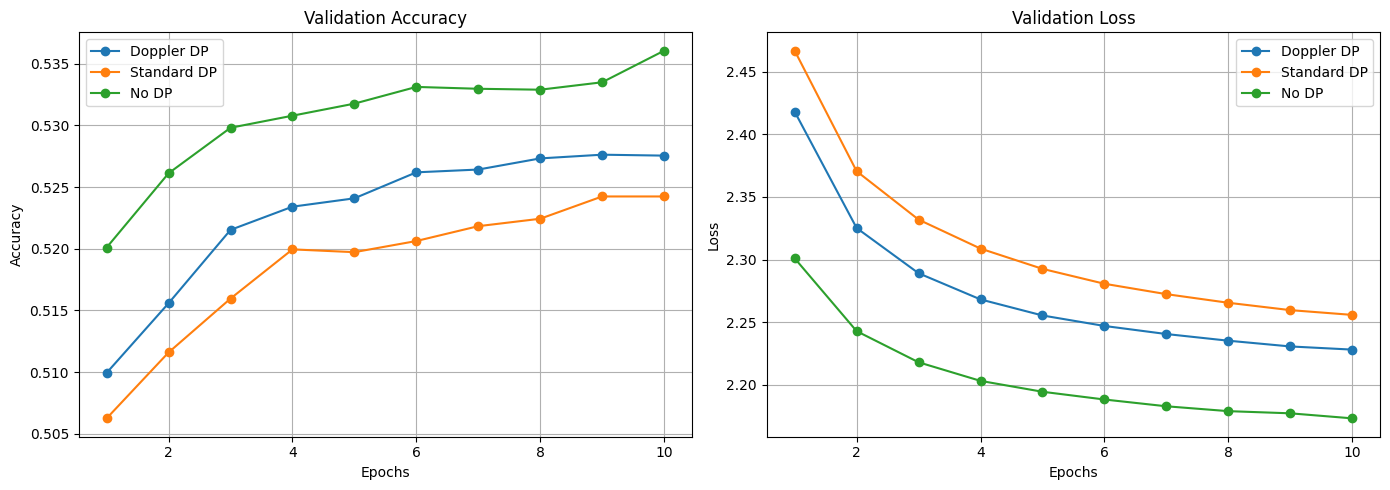

In [ ]:
results = {}
results["Doppler DP"] = run_experiment("Doppler DP", use_dp=True, use_doppler=True)
results["Standard DP"] = run_experiment("Standard DP AdamW", use_dp=True, use_doppler=False)
results["No DP"] = run_experiment("No DP", use_dp=False, use_doppler=False)

epochs = range(1, EPOCHS + 1)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

for name, data in results.items():
    ax1.plot(epochs, data["acc"], marker='o', label=name)
    ax2.plot(epochs, data["loss"], marker='o', label=name)

ax1.set_title("Validation Accuracy")
ax1.set_xlabel("Epochs")
ax1.set_ylabel("Accuracy")
ax1.legend()
ax1.grid(True)

ax2.set_title("Validation Loss")
ax2.set_xlabel("Epochs")
ax2.set_ylabel("Loss")
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()